# 08 -- From-Scratch Text-to-Image Retrieval (Mini-ResNet image + Bi-LSTM text)

## Approach

Same overall recipe as notebook 07 (random init, no pretrained weights, contrastive InfoNCE, two tokenizer variants), but with a classical 2017-era architecture:

- **Image encoder:** ResNet-18 layout (stem -> 4 stages of basic blocks, channels 64/128/256/512) -> global average pool -> 512d
- **Text encoder:** token embedding (256d) -> 2-layer bidirectional LSTM (hidden=256) -> masked mean pool -> 512d
- **Joint head:** 256-d L2-normalized projections
- **Loss:** in-batch hard-negative InfoNCE (`HardNegativeInfoNCELoss`)

CNNs converge faster than ViTs from scratch on small datasets, so this notebook also serves as a fairer absolute lower-bound baseline.

Tracked end-to-end via Weights & Biases (project: `nsiete-flickr30k-clip`).


In [1]:
import os
import sys
import gc
import time
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from src.config import (
    EMBEDDINGS_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    WANDB_PROJECT,
    get_device,
    set_seeds,
)
from src.data import load_karpathy_splits, get_all_captions_flat
from src.evaluation import (
    evaluate_text_to_image,
    save_results,
    load_results,
    print_results_table,
)
from src.training import (
    ScratchRetrievalDataset,
    make_scratch_collate_fn,
    HardNegativeInfoNCELoss,
    get_optimizer,
    get_scheduler,
    training_step,
    run_validation_scratch,
    encode_images_scratch,
    encode_texts_scratch,
    init_wandb,
    log_train_step,
    log_val_metrics,
    log_summary,
    log_artifact,
    finish_wandb,
)
from src.scratch_model import (
    build_cnn_dual,
    build_image_transform,
    count_params,
)
from src.scratch_tokenizer import WordTokenizer, ClipBPETokenizer
from src.visualize import plot_training_curves, plot_recall_comparison

set_seeds(42)
device = get_device()

# CUDA performance knobs (see notebook 07 for the full explanation).
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA capability: {torch.cuda.get_device_capability(0)}")
    print(f"  VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
  GPU: NVIDIA GeForce RTX 5090
  CUDA capability: (12, 0)
  VRAM total: 33.7 GB


## 2. Load data


In [2]:
splits = load_karpathy_splits()

train_captions, train_gt = get_all_captions_flat(splits["train"])
val_captions, val_gt = get_all_captions_flat(splits["val"])
test_captions, test_gt = get_all_captions_flat(splits["test"])

print(f"Train: {len(splits['train'])} images, {len(train_captions)} captions")
print(f"Val:   {len(splits['val'])} images, {len(val_captions)} captions")
print(f"Test:  {len(splits['test'])} images, {len(test_captions)} captions")


  train: 29000 images
  val: 1014 images
  test: 1000 images


Train: 29000 images, 145000 captions
Val:   1014 images, 5070 captions
Test:  1000 images, 5000 captions


## 3. Image transforms (ImageNet stats; standalone, no CLIPProcessor)


In [3]:
train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)

sample_pixels = eval_transform(splits["test"][0]["image"].convert("RGB"))
print(f"image tensor shape: {tuple(sample_pixels.shape)}, dtype: {sample_pixels.dtype}")


image tensor shape: (3, 224, 224), dtype: torch.float32


## 4. Hyperparameters


In [4]:
TOKENIZER_VARIANTS = ["word", "bpe"]
NUM_EPOCHS = int(os.environ.get("EPOCH_OVERRIDE", "30"))

BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "512" if device.type == "cuda" else "64"))

LR = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
JOINT_DIM = 256
ARCH_TAG = "cnn"

NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"

print(
    f"NUM_EPOCHS={NUM_EPOCHS} BATCH_SIZE={BATCH_SIZE} LR={LR} "
    f"WEIGHT_DECAY={WEIGHT_DECAY} WARMUP_RATIO={WARMUP_RATIO}\n"
    f"NUM_WORKERS={NUM_WORKERS} PREFETCH_FACTOR={PREFETCH_FACTOR} "
    f"AMP={USE_AMP} ({AMP_DTYPE})"
)


NUM_EPOCHS=30 BATCH_SIZE=256 LR=0.001 WEIGHT_DECAY=0.0001 WARMUP_RATIO=0.1
NUM_WORKERS=12 PREFETCH_FACTOR=4 AMP=True (torch.bfloat16)


## 5. Training loop (both tokenizer variants)


In [5]:
RUN_TRAINING = True

results_per_variant: dict[str, dict] = {}
history_per_variant: dict[str, dict] = {}

if RUN_TRAINING:
    for tok_name in TOKENIZER_VARIANTS:
        run_name = f"scratch_{ARCH_TAG}_{tok_name}"
        print(f"\n{'='*70}\n>>> Variant: {run_name}\n{'='*70}")

        if tok_name == "word":
            tokenizer = WordTokenizer.from_train_captions(train_captions, max_length=32)
            print(f"WordTokenizer vocab_size={tokenizer.vocab_size}, "
                  f"unk_rate(val)={tokenizer.unk_rate(val_captions):.4f}")
        else:
            tokenizer = ClipBPETokenizer(max_length=32)
            print(f"ClipBPETokenizer vocab_size={tokenizer.vocab_size}")

        model = build_cnn_dual(
            vocab_size=tokenizer.vocab_size,
            max_length=tokenizer.max_length,
            pad_token_id=tokenizer.pad_token_id,
            joint_dim=JOINT_DIM,
        ).to(device)
        n_params = count_params(model)
        print(f"Model parameters: {n_params:,}")

        train_dataset = ScratchRetrievalDataset(splits["train"], image_transform=train_transform)
        loader_kwargs = dict(
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=make_scratch_collate_fn(tokenizer),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
            drop_last=True,
        )
        if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
            loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        train_loader = DataLoader(train_dataset, **loader_kwargs)
        steps_per_epoch = len(train_loader)
        total_steps = steps_per_epoch * NUM_EPOCHS
        print(f"Batches/epoch: {steps_per_epoch}, total steps: {total_steps}")

        # No GradScaler -- bf16 keeps fp32 dynamic range.
        loss_fn = HardNegativeInfoNCELoss(temperature=0.07)
        optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_scheduler(optimizer, total_steps, warmup_ratio=WARMUP_RATIO)

        save_dir = MODELS_DIR / run_name
        save_dir.mkdir(parents=True, exist_ok=True)
        tokenizer.save(save_dir)

        run = init_wandb(
            run_name=run_name,
            config={
                "approach": "scratch",
                "architecture": ARCH_TAG,
                "tokenizer": tok_name,
                "vocab_size": tokenizer.vocab_size,
                "max_text_length": tokenizer.max_length,
                "joint_dim": JOINT_DIM,
                "trainable_params": n_params,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "num_epochs": NUM_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
                "max_grad_norm": MAX_GRAD_NORM,
                "temperature": 0.07,
                "hard_negative_weight": 2.0,
                "loss": "HardNegativeInfoNCE",
                "amp": device.type == "cuda",
                "seed": 42,
                "device": str(device),
            },
            tags=["scratch", ARCH_TAG, tok_name],
        )
        try:
            import wandb
            wandb.watch(model, log="gradients", log_freq=200)
        except Exception:
            pass

        best_val_r1 = 0.0
        train_losses: list[float] = []
        val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
        global_step = 0

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_losses: list[float] = []
            ep_start = time.time()
            for batch in train_loader:
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(model, batch, loss_fn, device)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()

                epoch_losses.append(metrics["loss"])
                train_losses.append(metrics["loss"])
                global_step += 1

                log_train_step(
                    {
                        "loss": metrics["loss"],
                        "acc_i2t": metrics["acc_i2t"],
                        "acc_t2i": metrics["acc_t2i"],
                        "lr": scheduler.get_last_lr()[0],
                    },
                    step=global_step,
                )

            avg_loss = float(np.mean(epoch_losses))

            val = run_validation_scratch(
                model,
                tokenizer,
                eval_transform,
                splits["val"],
                val_captions,
                val_gt,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
            )
            for k in ["R@1", "R@5", "R@10"]:
                val_metrics_history[k].append(val[k])

            log_val_metrics({**val, "epoch_loss": avg_loss}, epoch=epoch)
            print(
                f"[{tok_name}] Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: "
                f"loss={avg_loss:.4f} | "
                f"Val R@1={val['R@1']:.3f} R@5={val['R@5']:.3f} R@10={val['R@10']:.3f}",
                flush=True,
            )

            if val["R@1"] > best_val_r1:
                best_val_r1 = val["R@1"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "epoch": epoch,
                        "val_results": val,
                        "loss": avg_loss,
                    },
                    save_dir / "best.pt",
                )
                print(f"[{tok_name}]   -> New best (R@1={best_val_r1:.3f}); checkpoint saved")

        print(f"[{tok_name}] Best val R@1: {best_val_r1:.3f}")

        ckpt = torch.load(save_dir / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        test_img_emb = encode_images_scratch(
            splits["test"], model, eval_transform, device=device, batch_size=EVAL_BATCH_SIZE
        )
        test_txt_emb = encode_texts_scratch(
            test_captions, model, tokenizer, device=device, batch_size=EVAL_BATCH_SIZE * 2
        )

        np.save(EMBEDDINGS_DIR / f"{run_name}_images_test.npy", test_img_emb)
        np.save(EMBEDDINGS_DIR / f"{run_name}_texts_test.npy", test_txt_emb)
        print(f"[{tok_name}] Cached test embeddings: imgs={test_img_emb.shape} txts={test_txt_emb.shape}")

        test_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
        save_results(test_results, run_name)
        print(f"[{tok_name}] Test results:")
        for k, v in test_results.items():
            print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

        log_summary(test_results, prefix="test")
        log_artifact(save_dir / "best.pt", name=run_name, artifact_type="model")
        finish_wandb()

        results_per_variant[run_name] = test_results
        history_per_variant[run_name] = {
            "train_losses": train_losses,
            "val_metrics_history": val_metrics_history,
        }

        del model, optimizer, scheduler, train_loader, train_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nAll variants done.")



>>> Variant: scratch_cnn_word


WordTokenizer vocab_size=9471, unk_rate(val)=0.0089


Model parameters: 16,493,376
Batches/epoch: 113, total steps: 3390


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/students/xvysnya/.netrc.


wandb: Currently logged in as: vysnyandrej (vysnyandrej-slovak-university-of-technology-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▃▃▄▄▅▄▅▄▆▅▆▄▆▆▆▇▇▇▇▇▇██
wandb: train/acc_t2i ▁▁▁▁▁▂▂▃▃▃▃▄▃▄▄▄▄▄▄▅▅▅▄▅▅▅▅▆▅▅▇▆█▇█▇▇▇██
wandb:    train/loss ██▇█▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:      train/lr ▄▅▅▆▆▇█████▇▇▇▇▇▇▇▇▆▆▆▆▆▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁
wandb: 
wandb: Run summary:
wandb:    test/MeanR 88.4352
wandb:  test/MedianR 28
wandb:      test/R@1 0.0624
wandb:     test/R@10 0.3084
wandb:      test/R@5 0.2046
wandb: train/acc_i2t 0.36719
wandb: train/acc_t2i 0.33594
wandb:    train/loss 2.52191
wandb:      train/lr 0
wandb: 


wandb: 🚀 View run scratch_cnn_bpe at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/fh9tv3qx
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260504_233229-fh9tv3qx/logs


wandb: WARNING Tried to log to step 29 that is less than the current step 3390. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.



All variants done.


## 6. Comparison vs all variants



  Scratch CNN vs everything
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
scratch_cnn_word              6.4%    21.8%    31.3%      29.0      88.9
scratch_cnn_bpe               6.2%    20.5%    30.8%      28.0      88.4
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.7%    88.2%    93.5%       1.0       4.7
CLIP B/32 Full FT            68.5%    90.1%    94.3%       1.0       3.8
CLIP B/32 + LoRA (r=8)       67.3%    89.4%    94.2%       1.0       4.0
Scratch ViT (word)            3.4%    12.9%    19.9%      61.0     141.1
Scratch ViT (BPE)             4.1%    12.5%    20.4%      59.0     142.4



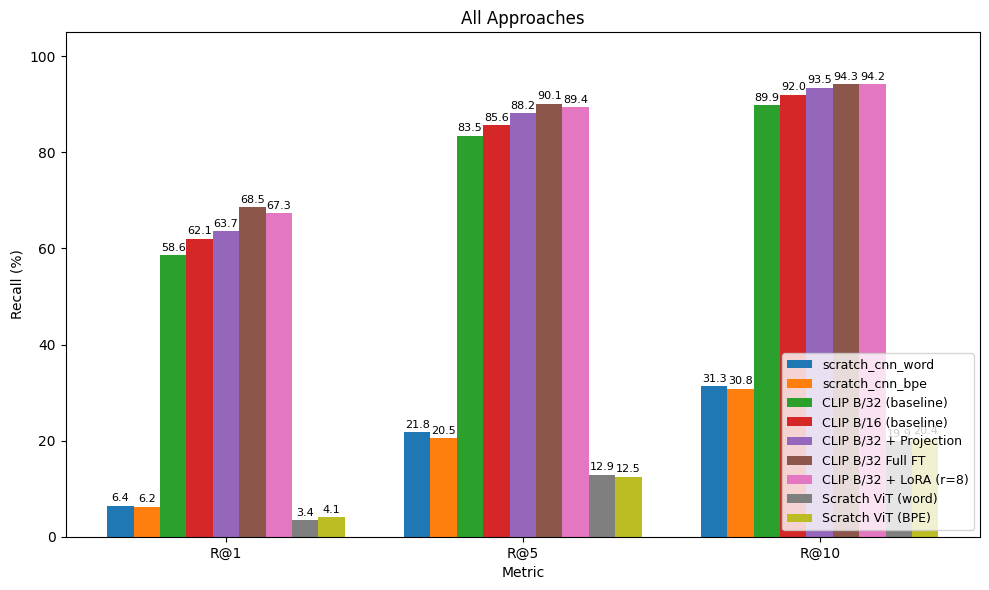

In [6]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    comparison: dict[str, dict] = dict(results_per_variant)

    for display, candidates in [
        ("CLIP B/32 (baseline)", ["baseline_b32", "baseline_clip-vit-b-32"]),
        ("CLIP B/16 (baseline)", ["baseline_b16", "baseline_clip-vit-b-16"]),
        ("CLIP B/32 + Projection", ["projection_head_b32"]),
        ("CLIP B/32 Full FT", ["full_finetune_b32"]),
        ("CLIP B/32 + LoRA (r=8)", ["lora_b32"]),
        ("Scratch ViT (word)", ["scratch_vit_word"]),
        ("Scratch ViT (BPE)", ["scratch_vit_bpe"]),
    ]:
        for fname in candidates:
            try:
                comparison[display] = load_results(fname)
                break
            except FileNotFoundError:
                continue

    print_results_table(comparison, title="Scratch CNN vs everything")
    plot_recall_comparison(comparison, title="All Approaches")


## 7. Training curves


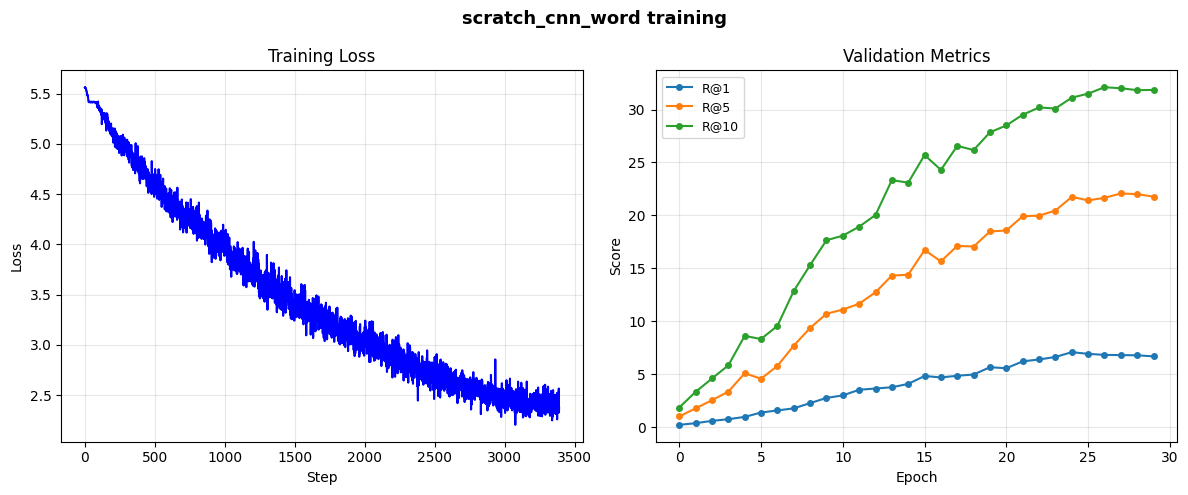

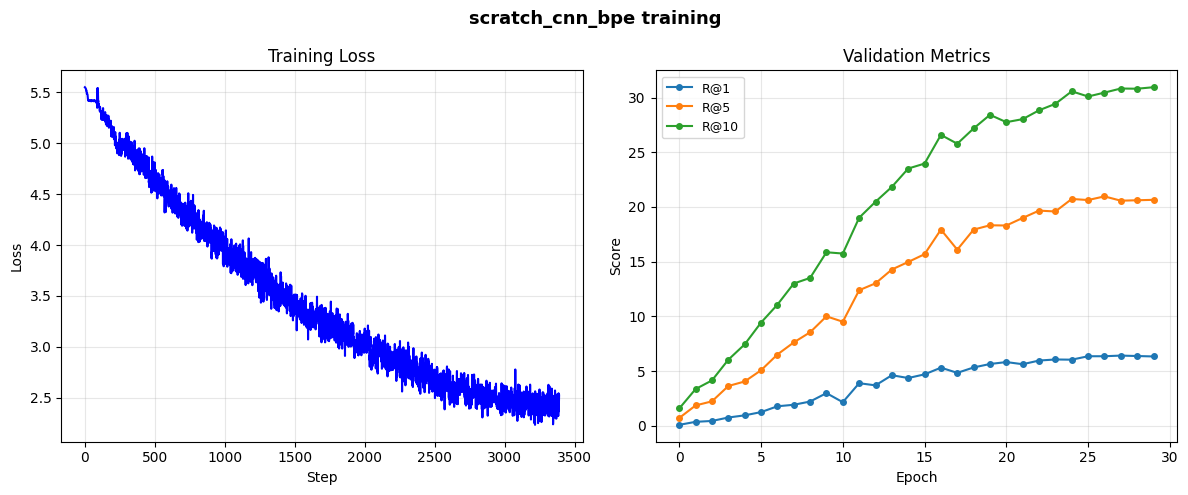

In [7]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    for run_name, hist in history_per_variant.items():
        plot_training_curves(
            hist["train_losses"], hist["val_metrics_history"], title=f"{run_name} training"
        )
